In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

In [2]:
df = pd.read_csv(r"E:\medical_report_cnn\eye\eye\full_df.csv")
df.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


In [3]:
df = df[['filename','labels']]
df.head()

,filename,labels
0,0_right.jpg,['N']
1,1_right.jpg,['N']
2,2_right.jpg,['D']
3,4_right.jpg,['D']
4,5_right.jpg,['D']


In [4]:
print(df['labels'].value_counts())

labels
['N']    2873
['D']    1608
['O']     708
['C']     293
['G']     284
['A']     266
['M']     232
['H']     128
Name: count, dtype: int64


In [5]:
classes = ["['N']","['C']","['D']","['G']"]
df = df[df['labels'].isin(classes)]
print(df['labels'].value_counts())

labels
['N']    2873
['D']    1608
['C']     293
['G']     284
Name: count, dtype: int64


In [6]:
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['labels'])
print(encoder.classes_)

["['C']" "['D']" "['G']" "['N']"]


In [7]:
image_folder = r"E:\medical_report_cnn\eye\eye\preprocessed_images"
df['filepath'] = df['filename'].apply(lambda x: os.path.join(image_folder,x))

In [8]:
print(df['filepath'].apply(os.path.exists).value_counts())

filepath
True    5058
Name: count, dtype: int64


In [9]:
train_df, test_df = train_test_split(df,test_size=0.20,random_state=42,stratify=df['label'])
train_df, val_df = train_test_split(train_df,test_size=0.20,random_state=42,stratify=train_df['label'])

In [10]:
train_datagen = ImageDataGenerator(rescale=1./255,rotation_range=20,zoom_range=0.2,horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
train_generator = train_datagen.flow_from_dataframe(dataframe=train_df,x_col='filepath',y_col='labels',target_size=(224,224),batch_size=32,class_mode='categorical')

Found 3236 validated image filenames belonging to 4 classes.


In [12]:
validation_generator = test_datagen.flow_from_dataframe(dataframe=val_df,x_col='filepath',y_col='labels',target_size=(224,224),batch_size=32,class_mode='categorical')
test_generator = test_datagen.flow_from_dataframe(dataframe=test_df,x_col='filepath',y_col='labels',target_size=(224,224),batch_size=32,class_mode='categorical',shuffle=False)

Found 810 validated image filenames belonging to 4 classes.
Found 1012 validated image filenames belonging to 4 classes.


In [13]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4,activation='softmax'))
model.summary()

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       9,437,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,861,188 (37.62 MB)

 Trainable params: 9,860,228 (37.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [15]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
checkpoint = tf.keras.callbacks.ModelCheckpoint('best_eye_model.keras',save_best_only=True)

In [16]:
history = model.fit(train_generator,validation_data=validation_generator,epochs=20,callbacks=[early_stop, checkpoint])

Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 424s 4s/step - accuracy: 0.4342 - loss: 5.3412 - val_accuracy: 0.4074 - val_loss: 3.4331
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 398s 4s/step - accuracy: 0.5377 - loss: 1.4727 - val_accuracy: 0.5272 - val_loss: 1.8497
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 409s 4s/step - accuracy: 0.5578 - loss: 1.1719 - val_accuracy: 0.5630 - val_loss: 1.8062
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 425s 4s/step - accuracy: 0.5643 - loss: 1.1160 - val_accuracy: 0.5654 - val_loss: 1.7288
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 395s 4s/step - accuracy: 0.5627 - loss: 1.1122 - val_accuracy: 0.5531 - val_loss: 1.1030
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - accuracy: 0.5627 - loss: 1.0616 - val_accuracy: 0.5679 - val_loss: 1.0124
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 446s 4s/step - accuracy: 0.5649 - loss: 1.0430 - val_accuracy: 0.5691 - val_loss: 1.0090
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 395s 4s/step - accuracy: 0.5652 - loss: 1.0432 - val_accu

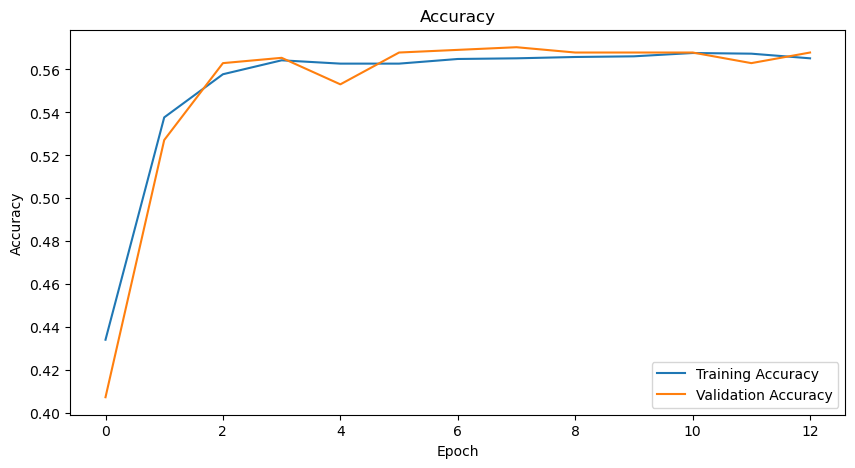

In [17]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

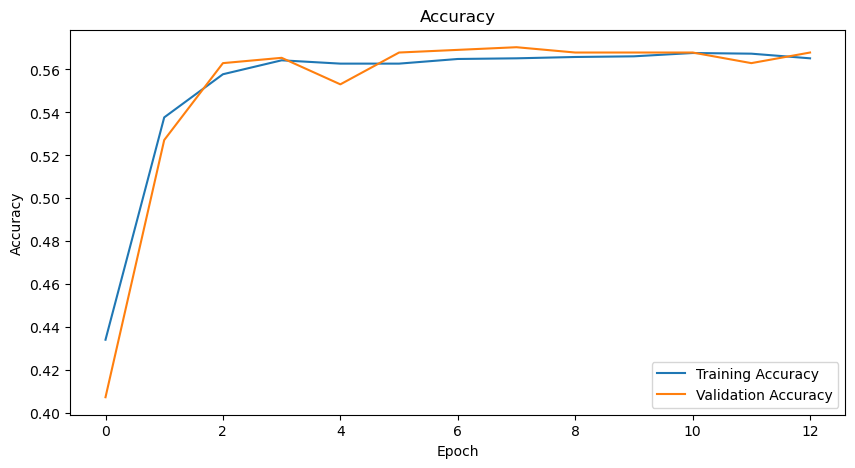

In [18]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [19]:
loss, accuracy = model.evaluate(test_generator)
print("Test Loss :",loss)
print("Test Accuracy :",accuracy*100,"%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 853ms/step - accuracy: 0.5682 - loss: 1.0075
Test Loss : 1.0074502229690552
Test Accuracy : 56.81818127632141 %


In [20]:
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions,axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 537ms/step


In [21]:
model.save("eye_disease_model.keras")
print("Model Saved Successfully")

Model Saved Successfully


In [22]:
loaded_model = tf.keras.models.load_model("eye_disease_model.keras")

In [23]:
from tensorflow.keras.preprocessing import image
img_path = r"E:\medical_report_cnn\eye\eye\preprocessed_images\5_left.jpg"
img = image.load_img(img_path,target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array,axis=0)
prediction = loaded_model.predict(img_array)
predicted_index = np.argmax(prediction)
print(predicted_index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
3
